data loading


In [33]:
!pip install kagglehub
!pip install transformers
!pip install transformers[torch]
!pip install 'accelerate>=0.26.0'
import kagglehub
!pip install --upgrade datasets
import pandas as pd
import os
import random
from datasets import Dataset
import datasets
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import AutoConfig
import torch
from torch.nn.functional import softmax
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import DataCollatorWithPadding
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from transformers import TrainingArguments,Trainer

from transformers import EarlyStoppingCallback
!pip install nlpaug
import nlpaug.augmenter.char as nac





# Download and get the dataset path
path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")
csv_path = os.path.join(path, "AI_Human.csv")

# Load into DataFrame
df = pd.read_csv(csv_path)
import pandas as pd

da = pd.read_parquet("hf://datasets/ardavey/human-ai-generated-text/data/train-00000-of-00001.parquet")
da = da.rename(columns={'label':'labels'})






huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


data cleaning 


In [34]:
# df.dropna(inplace=True)
# df.drop_duplicates(inplace=True)
# class Text:
#     def __init__(self, text, generated):
#         self.generated = generated
#         self.text = text

# # Create a list of Text objects from the DataFrame
# data = [Text(row['text'], row['generated']) for _, row in df.iterrows()]

# #So, for _, row in df.iterrows() means "for each row in the DataFrame, ignore the index, and use the row data."
# subset_size = 10000 # You can adjust the size of the subset
# data_subset = data[:subset_size]

# # Initialize a character augmenter (KeyboardAug is an example, you can choose others)
# aug = nac.KeyboardAug()
# def inject_noise_batch(text_objects, augmenter):
#     """Injects noise into a batch of Text objects."""
#     noisy_batch = []
#     for item in text_objects:
#         # Ensure the augmented output is a string or handle list output if augmenter returns list
#         augmented_text = augmenter.augment(item.text)
#         if isinstance(augmented_text, list):
#             # Assuming augmenter returns a list of augmented strings
#             noisy_batch.append((augmented_text[0], item.generated))
#         else:
#             noisy_batch.append((augmented_text, item.generated))
#     return noisy_batch
# # Inject noise in batches into the subset
# batch_size = 1000 # You can adjust the batch size
# augmented_data_subset = []



         
# # ai_text = list(filter(lambda x : x.generated == 1, augmented_dataset))
# # human_text = list(filter(lambda x : x.generated == 0 , augmented_dataset))
# # print(human_text[2].text)
# # human_text_shrunk = human_text[:len(ai_text)]
# # data = ai_text + human_text_shrunk
# # random.shuffle(data)
# # output = [t.generated for t in data]
# # texts = [t.text for t in data]
# # new_df = pd.DataFrame({'text': texts, 'labels': output})


# # # convert to a hugging face dataset

# # dataset = Dataset.from_pandas(new_df)
# # dataset = dataset.train_test_split(test_size=0.2)


# # Select a subset of the data for augmentation





# for i in range(0, len(data_subset), batch_size):
#     batch = data_subset[i:i+batch_size]
#     augmented_batch = inject_noise_batch(batch, aug)
#     augmented_data_subset.extend([Text(text, label) for text, label in augmented_batch])

# # Combine original subset and augmented data
# combined_data = data_subset + augmented_data_subset
# random.shuffle(combined_data)

# # Create a new DataFrame from the combined data
# output_combined = [t.generated for t in combined_data]
# texts_combined = [t.text for t in combined_data]
# new_df_augmented = pd.DataFrame({'text': texts_combined, 'labels': output_combined})

# # Convert to a hugging face dataset
# dataset = Dataset.from_pandas(new_df_augmented)
# dataset= dataset.train_test_split(test_size=0.2)



df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

class Text:
    def __init__(self, text, generated):
        self.generated = generated
        self.text = text

data = [Text(row['text'], row['generated']) for _, row in df.iterrows()]


subset_size = 10000
data_subset = data[:subset_size]                # to be augmented
remaining_data = data[subset_size:]             # rest of original data (clean)


aug = nac.KeyboardAug()

def inject_noise_batch(text_objects, augmenter):
    noisy_batch = []
    for item in text_objects:
        augmented_text = augmenter.augment(item.text)
        if isinstance(augmented_text, list):
            noisy_batch.append((augmented_text[0], item.generated))
        else:
            noisy_batch.append((augmented_text, item.generated))
    return noisy_batch

batch_size = 1000
augmented_data_subset = []

for i in range(0, len(data_subset), batch_size):
    batch = data_subset[i:i+batch_size]
    augmented_batch = inject_noise_batch(batch, aug)
    augmented_data_subset.extend([Text(text, label) for text, label in augmented_batch])


final_training_data = remaining_data + augmented_data_subset
random.shuffle(final_training_data)


texts = [t.text for t in final_training_data]
labels = [t.generated for t in final_training_data]
df_final = pd.DataFrame({'text': texts, 'labels': labels})

dataset = Dataset.from_pandas(df_final)
dataset = dataset.train_test_split(test_size=0.2)
new_test = Dataset.from_pandas(da)



initalize the tockenizer and the model

In [36]:
# Use a pipeline as a high-level helper
# from transformers import pipeline

# pipe = pipeline("fill-mask", model="distilbert/distilbert-base-uncased")(faster method but for testing model only not for fine tuning it )

# Load model directly

config = AutoConfig.from_pretrained(
    "distilbert-base-uncased",
    
    hidden_dropout_prob=0.3,  # Default is 0.1 — increase to 0.3 or 0.4
)
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", torch_dtype="auto",config=config)




Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


split data and tokenize data



In [37]:
train_ds = dataset['train'].shuffle(seed=42)
test_ds = dataset['test'].shuffle(seed=42)


def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding=True,return_tensors='pt')



tokenized_train = train_ds.map(tokenize, batched=True)
tokenized_test = test_ds.map(tokenize, batched=True)
tokenized_new_test = new_test.map(tokenize,batched = True)

tokenized_train.set_format('torch')
tokenized_test.set_format('torch')
tokenized_new_test.set_format('torch')





# can also initlaize directly using lambda

# batch_size = 50000
# all_tokenized = []
# for i in range(0, len(data), batch_size):
#     texts = [item.text for item in data[i:i+batch_size]]
#     tokenized = tokenizer(
#         texts,
#         padding=True,
#         truncation=True,
#         return_tensors="pt"
#     )
#     all_tokenized.append(tokenized)



Map: 100%|██████████| 488/488 [00:00<00:00, 11593.10 examples/s]


changes for insert into the model 

In [41]:

# tokenized_train = tokenized_train.remove_columns('text')
# tokenized_test = tokenized_test.remove_columns('text')
# tokenized_new_test = tokenized_new_test.remove_columns('text')
print(tokenized_train[8])
tokenized_train = tokenized_train.cast_column("labels", datasets.Value("int64"))
tokenized_test= tokenized_test.cast_column("labels", datasets.Value("int64"))
tokenized_new_test = tokenized_new_test.cast_column("labels",datasets.Value("int64"))


{'text': 'Dear, State Senator\n\nI have come to a conclusion that keeping the Electoral College would be a much better process instead of an unorganized popular vote. The electoral college is a great process with the votes in congress and a vote of the qualified citizens. It is more organized with five benefits of certainty of outcome, trans- regional appeal, winner-take-all method, big states, and avoiding run-off elections. These benefits help the elections go more smoothly. The Electoral College process has a selection of electors that vote for president and vice president, and the counting of electoral votes by congress.\n\n" The dispute over outcome of an electoral college is possible if it happened in 2000 but is less likely than a dispute over the popular vote". "For example, Obama got sixty-one point seven percent of the electoral vote to only fofty-one point three percent of popular votes cast FRM him and Romney..." \nSo the reason for a less likely dispute over a popular vote

Casting the dataset: 100%|██████████| 488/488 [00:00<00:00, 223500.80 examples/s]


set up evaluation metrics


In [43]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }
    


set up trainer


In [44]:
# Training Arguments

args = TrainingArguments(
    output_dir="model_output",
    eval_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=1,
    logging_dir='./logs',
    logging_steps=10,
    learning_rate=2e-5,
    metric_for_best_model="eval_loss"
   
    
)



#  Create Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_new_test,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


/tmp/ipykernel_102625/1891650245.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [45]:
trainer.train()

Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:278: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.000000,5.869013,0.538934,0.700399,0.538934,1.000000


/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:278: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)
/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:278: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or

KeyboardInterrupt: 

In [21]:
predictions= trainer.predict(tokenized_new_test)
logits = predictions.predictions
true_labels = predictions.label_ids

# Convert logits to predicted class (0 or 1)
pred_labels = np.argmax(logits, axis=1)
print(tokenized_test[2])


/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:278: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)


{'labels': tensor(0), 'input_ids': tensor([  101,  2651,  1045,  2052,  2066,  2000,  2831,  2055,  2493, 20185,
         1998,  6577,  2015,  1012,  2493,  2024, 17612,  2138,  2027,  2215,
         2000,  5589,  1999,  2998,  1010,  1998,  2060,  3450,  1998,  2027,
         2228,  2009,  2003,  2025,  2157,  2008,  2027,  2031,  2000,  2031,
         1037,  3694,  1997,  1038,  2779,  2000,  4607,  1037,  4368,  2465,
         2061,  6203,  4054,  1045,  2052,  2066,  2017,  2000,  2562,  1996,
         3627,  1997,  4033,  2075,  1037,  1039,  2779,  2000,  4607,  4368,
         2030,  2060,  2465,  2800,  1010,  1998,  1045,  2052,  4067,  2017,
         2065,  2017,  2052,  2025,  2689,  2009,  2005,  1996,  2493,  2008,
         2024,  2725,  2204,  1999,  2045,  2465,  1005,  1055,  1998,  2045,
         2147,  1012,  3076,  7615,  1045,  2228,  2017,  2323,  2025,  2689,
         1996,  2816,  3343,  2138,  2009,  2052,  2025,  2022,  4189,  1012,
         1045,  2228,  2065, 

In [22]:
print(predictions)

PredictionOutput(predictions=array([[-6.6076922,  7.903444 ],
       [-6.58312  ,  7.892636 ],
       [-6.632264 ,  7.9161386],
       [-6.6055584,  7.8985863],
       [-6.633013 ,  7.911389 ],
       [-6.6276565,  7.9203243],
       [-6.605608 ,  7.9197755],
       [-6.5984693,  7.8856587],
       [-6.662833 ,  7.9446745],
       [-6.6050644,  7.9292626],
       [-6.6091924,  7.898125 ],
       [-6.6178236,  7.9261756],
       [-6.62168  ,  7.937753 ],
       [-6.6505475,  8.002044 ],
       [-6.678841 ,  7.9915504],
       [-6.635793 ,  7.9273534],
       [-6.592412 ,  7.864341 ],
       [-6.6123214,  7.9342284],
       [-6.639861 ,  7.936048 ],
       [-6.643203 ,  7.9478   ],
       [-6.647777 ,  7.940071 ],
       [-6.636188 ,  7.952307 ],
       [-6.6234536,  7.9354167],
       [-6.6244926,  7.921655 ],
       [-6.619977 ,  7.9192047],
       [-6.669442 ,  7.976719 ],
       [-6.458043 ,  7.7556915],
       [-6.6251764,  7.9054995],
       [-6.6243877,  7.915644 ],
       [-6.646

In [23]:
trainer.save_model("ai-human-detector-distilbert")
tokenizer.save_pretrained("ai-human-detector-distilbert")

('ai-human-detector-distilbert/tokenizer_config.json',
 'ai-human-detector-distilbert/special_tokens_map.json',
 'ai-human-detector-distilbert/vocab.txt',
 'ai-human-detector-distilbert/added_tokens.json',
 'ai-human-detector-distilbert/tokenizer.json')

In [24]:
trainer.evaluate()

/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:278: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)


{'eval_loss': 6.667778968811035,
 'eval_accuracy': 0.5389344262295082,
 'eval_f1': 0.7003994673768309,
 'eval_precision': 0.5389344262295082,
 'eval_recall': 1.0,
 'eval_runtime': 0.251,
 'eval_samples_per_second': 1944.035,
 'eval_steps_per_second': 63.739,
 'epoch': 2.0}

In [32]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from torch.nn.functional import softmax


model = AutoModelForSequenceClassification.from_pretrained("ai-human-detector-distilbert")
tokenizer = AutoTokenizer.from_pretrained("ai-human-detector-distilbert")

text= ''''''
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
with torch.no_grad():
    outputs = model(**inputs)
    probs = softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred].item()

label = "AI" if pred == 1 else "Human"
print(f"Prediction: {label} (confidence: {confidence:.2f})")


Prediction: AI (confidence: 1.00)


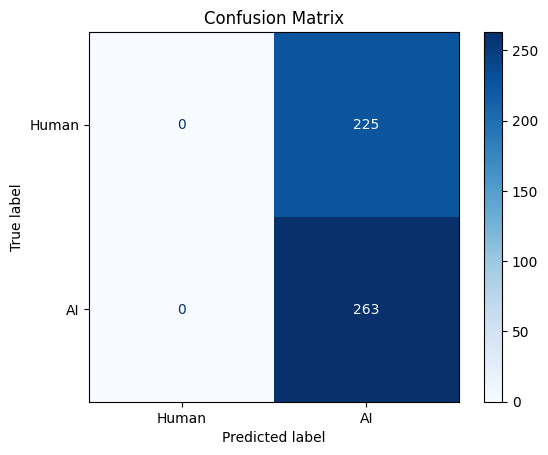

In [30]:


# Replace these with your actual labels
# true_labels = [...]
# pred_labels = [...]

# Example (you can replace these with your real data)
# true_labels = [0, 1, 0, 1, 1, 0]
# pred_labels = [0, 1, 1, 1, 0, 0]

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human", "AI"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
